In [ ]:
!pip install spatialdata "anndata==0.12.2" "scanpy==1.11.4" "squidpy==1.6.5"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tarfile

tar_path = "/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/Croped_Images.tar"
extract_path = "/content/Cropped_Images"

with tarfile.open(tar_path, "r:*") as tar:
    tar.extractall(path=extract_path)

/tmp/ipython-input-1915049939.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


## Import


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

Using CPU


In [6]:
import math
import os
import sys
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import spatialdata as sd
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
import gc
import sklearn.metrics
from sklearn.preprocessing import Normalizer, StandardScaler

import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


# PCA & segmentation

## UNI

In [ ]:
!pip install igraph
!pip install leidenalg

In [7]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Coronal_Embeddings/Xenium_Morpho_integrated.h5ad")

In [100]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/UNI.h5ad")
M = edata.obsm['UNI']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

edata.obs_names = [cid[61:] for cid in edata.obs['cell_id']]
common_cells = ad.obs_names.intersection(edata.obs_names)
ad.obsm['morpho'][ad.obs_names.get_indexer(common_cells)] = \
  edata.obsm['UNI'][edata.obs_names.get_indexer(common_cells)]

adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho']

In [101]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(adata.obsm['p_Morpho_Embedding'])
adata.obsm['Morpho_PCA'] = X_reduced

In [102]:
sc.pp.neighbors(adata, use_rep='Morpho_PCA', key_added = 'PCA_added', n_neighbors=20)

In [103]:
sc.tl.leiden(adata, obsp='PCA_added_connectivities', key_added='FM1_clusters', resolution=0.4)

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


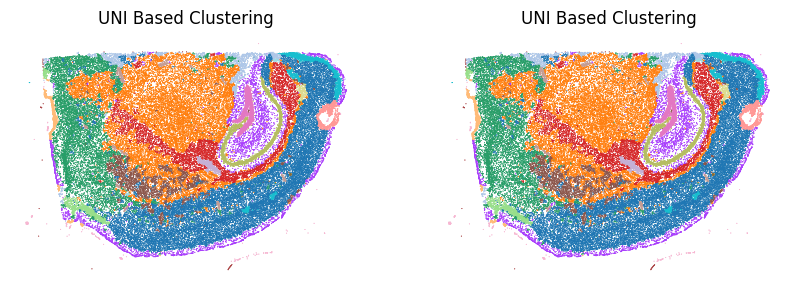

In [106]:
axes = plt.subplots(1, 2, figsize=(10, 6))[1].flatten()

sq.pl.spatial_scatter(
    adata, color=['FM1_clusters'], title = ['UNI Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adata, color=['FM1_clusters'], title = ['UNI Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

In [ ]:
adata.uns.pop('FM_clusters_colors')

In [ ]:
adata.obs['UNI_clusters'] = adata.obs['FM_clusters']

## h_optimus

In [67]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/h_optimus.h5ad")
M = edata.obsm['h_optimus']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

edata.obs_names = [cid[61:] for cid in edata.obs['cell_id']]
common_cells = ad.obs_names.intersection(edata.obs_names)
ad.obsm['morpho'][ad.obs_names.get_indexer(common_cells)] = \
  edata.obsm['h_optimus'][edata.obs_names.get_indexer(common_cells)]

adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho']

In [68]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(adata.obsm['p_Morpho_Embedding'])
adata.obsm['Morpho_PCA'] = X_reduced

In [84]:
sc.pp.neighbors(adata, use_rep='Morpho_PCA', key_added = 'PCA_added', n_neighbors=20)

In [88]:
sc.tl.leiden(adata, obsp='PCA_added_connectivities', key_added='FM2_clusters', resolution=0.4)

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


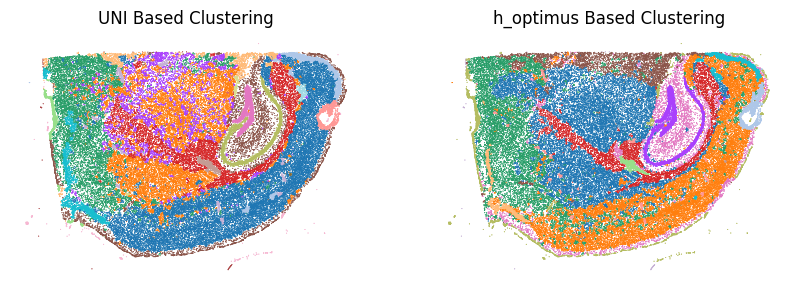

In [91]:
axes = plt.subplots(1, 2, figsize=(10, 6))[1].flatten()

sq.pl.spatial_scatter(
    adata, color=['FM1_clusters'], title = ['UNI Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adata, color=['FM2_clusters'], title = ['h_optimus Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

In [ ]:
adata.uns.pop('FM2_clusters_colors')

In [44]:
adata.obs['h_optimus_clusters'] = adata.obs['FM_clusters']

## virchow

In [ ]:
!pip install igraph
!pip install leidenalg

In [94]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Coronal_Embeddings/Xenium_Morpho_integrated.h5ad")

In [95]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/virchow.h5ad")
M = edata.obsm['virchow']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

edata.obs_names = [cid[61:] for cid in edata.obs['cell_id']]
common_cells = ad.obs_names.intersection(edata.obs_names)
ad.obsm['morpho'][ad.obs_names.get_indexer(common_cells)] = \
  edata.obsm['virchow'][edata.obs_names.get_indexer(common_cells)]

adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho']

In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(adata.obsm['p_Morpho_Embedding'])
adata.obsm['Morpho_PCA'] = X_reduced

In [97]:
sc.pp.neighbors(adata, use_rep='Morpho_PCA', key_added = 'PCA_added', n_neighbors=20)

In [98]:
sc.tl.leiden(adata, obsp='PCA_added_connectivities', key_added='FM3_clusters', resolution=0.4)

In [ ]:
adata.uns.pop('FM2_clusters_colors')

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


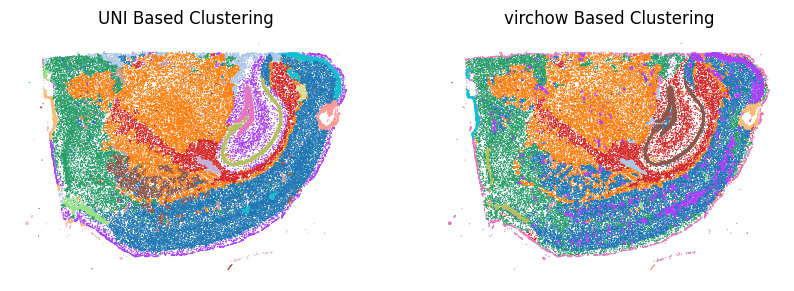

In [107]:
axes = plt.subplots(1, 2, figsize=(10, 6))[1].flatten()

sq.pl.spatial_scatter(
    adata, color=['FM1_clusters'], title = ['UNI Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adata, color=['FM3_clusters'], title = ['virchow Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

## Only Genes

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Coronal_Embeddings/Xenium_Morpho_integrated.h5ad")

In [108]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(adata.X)
adata.obsm['PCA'] = X_reduced

In [109]:
sc.pp.neighbors(adata, use_rep='PCA', key_added = 'PCA_added', n_neighbors=20)

In [115]:
sc.tl.leiden(adata, obsp='PCA_added_connectivities', key_added='FM4_clusters', resolution=0.4)

In [ ]:
adata.uns.pop('FM4_clusters_colors')

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


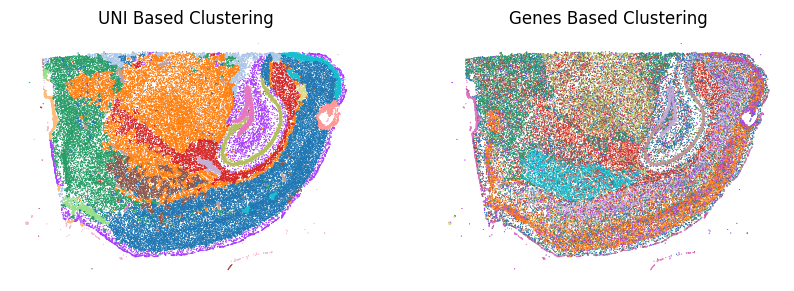

In [117]:
axes = plt.subplots(1, 2, figsize=(10, 6))[1].flatten()

sq.pl.spatial_scatter(
    adata, color=['FM1_clusters'], title = ['UNI Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adata, color=['FM4_clusters'], title = ['Genes Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

## Genes + Morpho

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(adata.X)
adata.obsm['PCA'] = X_reduced

In [118]:
edata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Mouse_Brain/FMs_3/virchow.h5ad")
M = edata.obsm['virchow']
ad = adata.copy()
ad.obsm["morpho"] = np.zeros_like(M)

edata.obs_names = [cid[61:] for cid in edata.obs['cell_id']]
common_cells = ad.obs_names.intersection(edata.obs_names)
ad.obsm['morpho'][ad.obs_names.get_indexer(common_cells)] = \
  edata.obsm['virchow'][edata.obs_names.get_indexer(common_cells)]

adata.obsm['p_Morpho_Embedding'] = ad.obsm['morpho']

In [119]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_reduced = pca.fit_transform(adata.obsm['p_Morpho_Embedding'])
adata.obsm['Morpho_PCA'] = X_reduced

In [120]:
sc.pp.neighbors(adata, use_rep='PCA', key_added = 'PCA_added', n_neighbors=20)
sc.pp.neighbors(adata, use_rep='Morpho_PCA', key_added = 'morpho_PCA_added', n_neighbors=20)

In [121]:
adata.obsp['connectivities'] = adata.obsp['PCA_added_connectivities'] + adata.obsp['morpho_PCA_added_connectivities']

In [130]:
sc.tl.leiden(adata, obsp='connectivities', key_added='FM5_clusters', resolution=0.8)

In [ ]:
adata.uns.pop('FM5_clusters_colors')

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


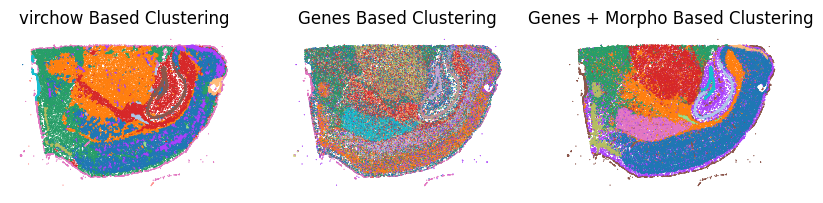

In [132]:
axes = plt.subplots(1, 3, figsize=(10, 9))[1].flatten()

sq.pl.spatial_scatter(
    adata, color=['FM3_clusters'], title = ['virchow Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adata, color=['FM4_clusters'], title = ['Genes Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

sq.pl.spatial_scatter(
    adata, color=['FM5_clusters'], title = ['Genes + Morpho Based Clustering'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[2]
    )